# Medical Costs Analysis


This analysis explores the factors that influence healthcare expenses using a medical insurance dataset. The goal is to understand how patient characteristics such as age, BMI, and number of children affect medical charges.

Key questions:

How do medical costs vary with age?

Does BMI influence healthcare expenses?

Are families with more children associated with higher healthcare costs?

Can medical charges be predicted using these variables?

In [1]:
#importing the libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [3]:
#loading the dataset 
df = pd.read_csv("insurance.csv")

In [4]:
#overview of the dataset 
print("Shape of dataset:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nData types and non-null counts:")
df.info()

print("\nSummary statistics:")
display(df.describe())


Shape of dataset: (1338, 7)

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520



Last 5 rows:


,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603



Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

Summary statistics:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
#missing value checks 
missing = df.isnull().sum()

print("\nMissing values by column:")
display(missing)

if missing.sum() == 0:
    print("No missing values were found in the dataset.")
else:
    plt.figure(figsize=(8, 4))
    missing[missing > 0].sort_values(ascending=False).plot(kind="bar")
    plt.title("Missing Values by Feature")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()



Missing values by column:


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

No missing values were found in the dataset.


## EDA

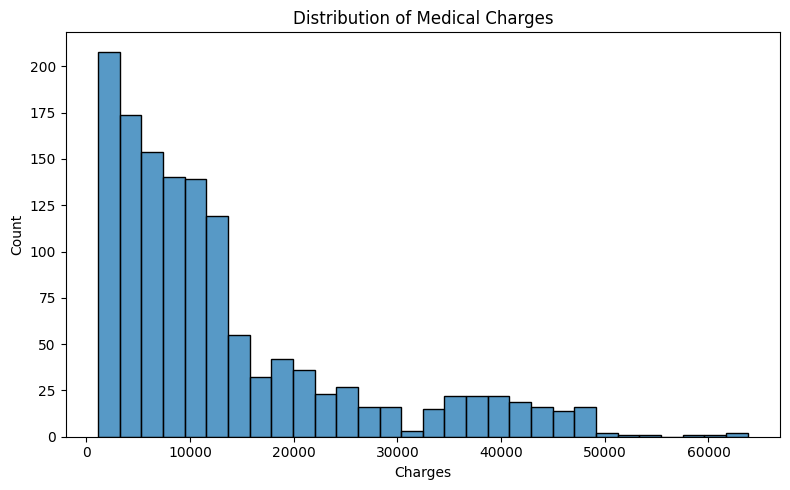

In [6]:
# Charges distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["charges"], bins=30)
plt.title("Distribution of Medical Charges")
plt.xlabel("Charges")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


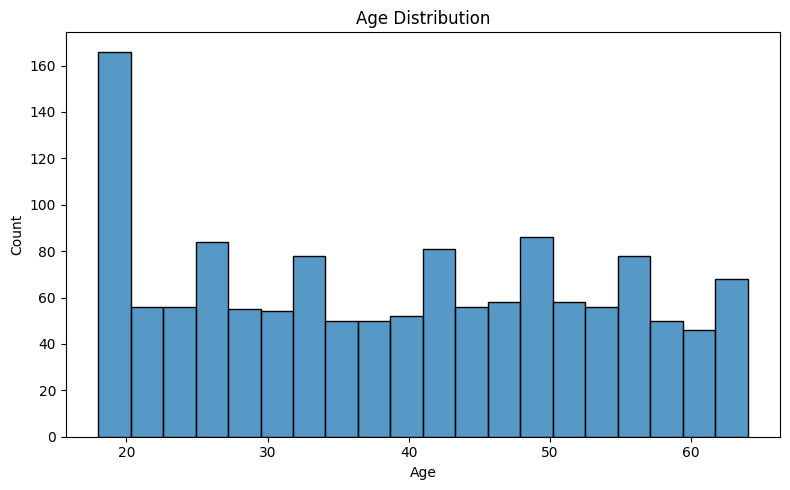

In [7]:
# Age distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



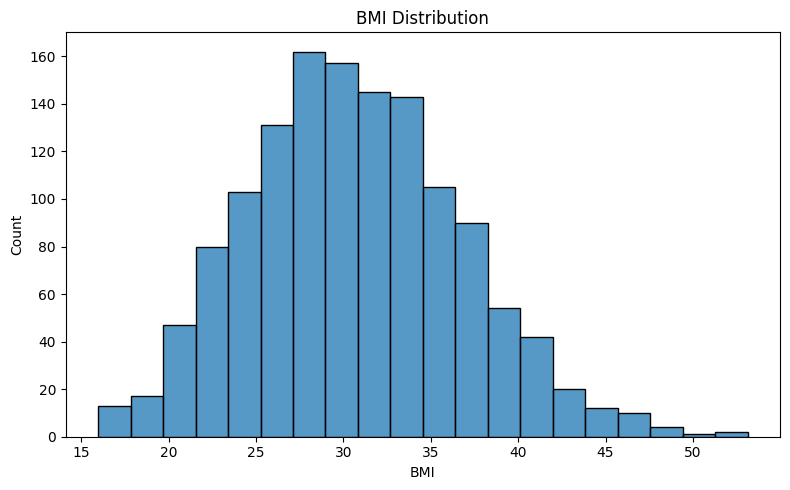

In [8]:
# BMI distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["bmi"], bins=20)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


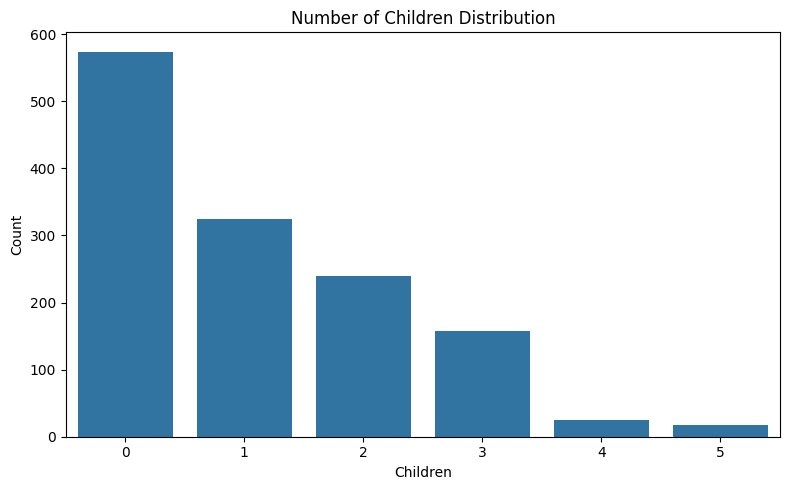

In [9]:
# Children distribution
plt.figure(figsize=(8, 5))
sns.countplot(x="children", data=df)
plt.title("Number of Children Distribution")
plt.xlabel("Children")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## Relationship Analysis 


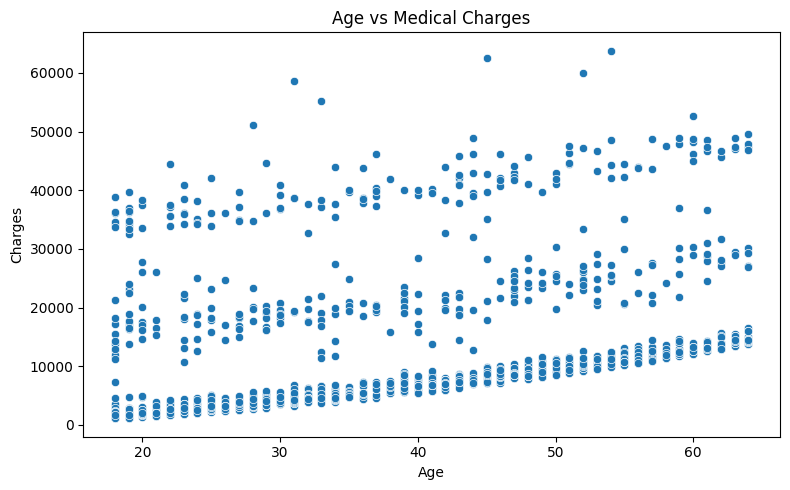

In [10]:
# Age vs charges
plt.figure(figsize=(8, 5))
sns.scatterplot(x="age", y="charges", data=df)
plt.title("Age vs Medical Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.tight_layout()
plt.show()


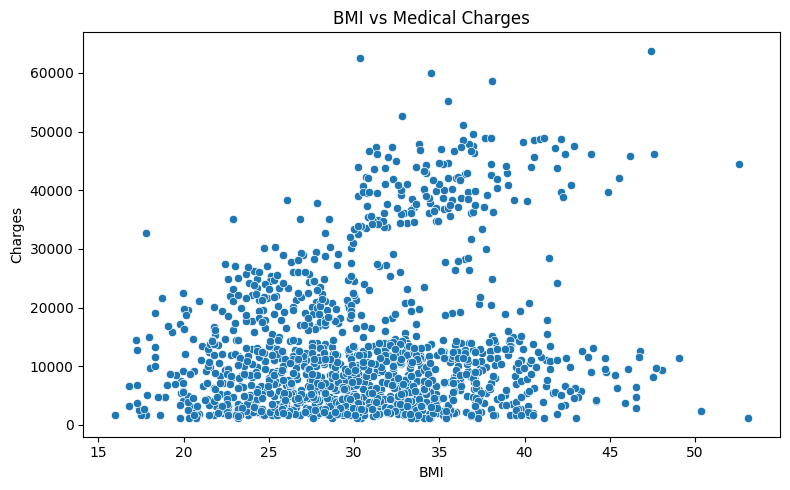

In [11]:
# BMI vs charges
plt.figure(figsize=(8, 5))
sns.scatterplot(x="bmi", y="charges", data=df)
plt.title("BMI vs Medical Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.tight_layout()
plt.show()


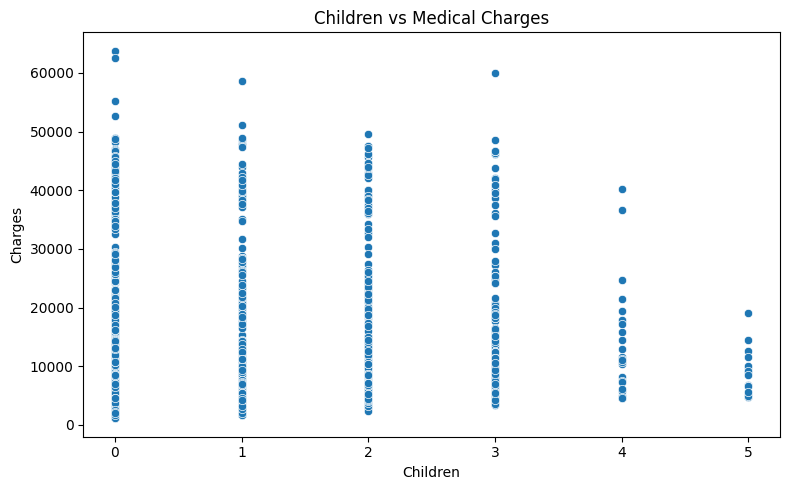

In [12]:
# Children vs charges - scatter
plt.figure(figsize=(8, 5))
sns.scatterplot(x="children", y="charges", data=df)
plt.title("Children vs Medical Charges")
plt.xlabel("Children")
plt.ylabel("Charges")
plt.tight_layout()
plt.show()


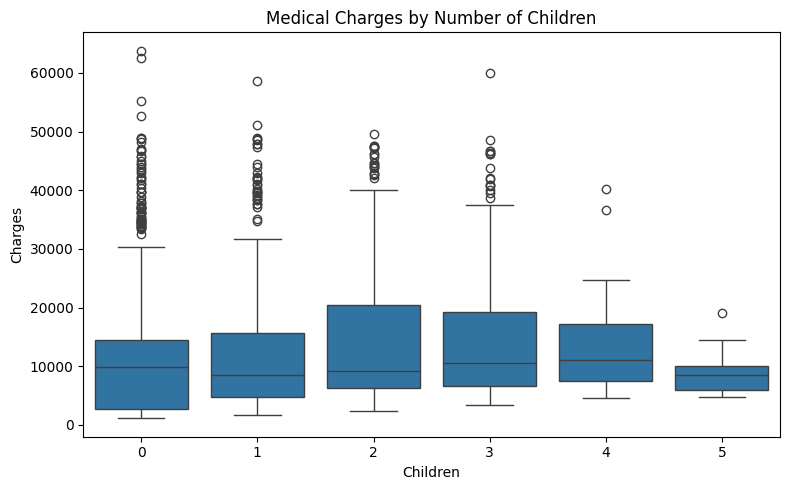

In [13]:
# Children vs charges - boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x="children", y="charges", data=df)
plt.title("Medical Charges by Number of Children")
plt.xlabel("Children")
plt.ylabel("Charges")
plt.tight_layout()
plt.show()


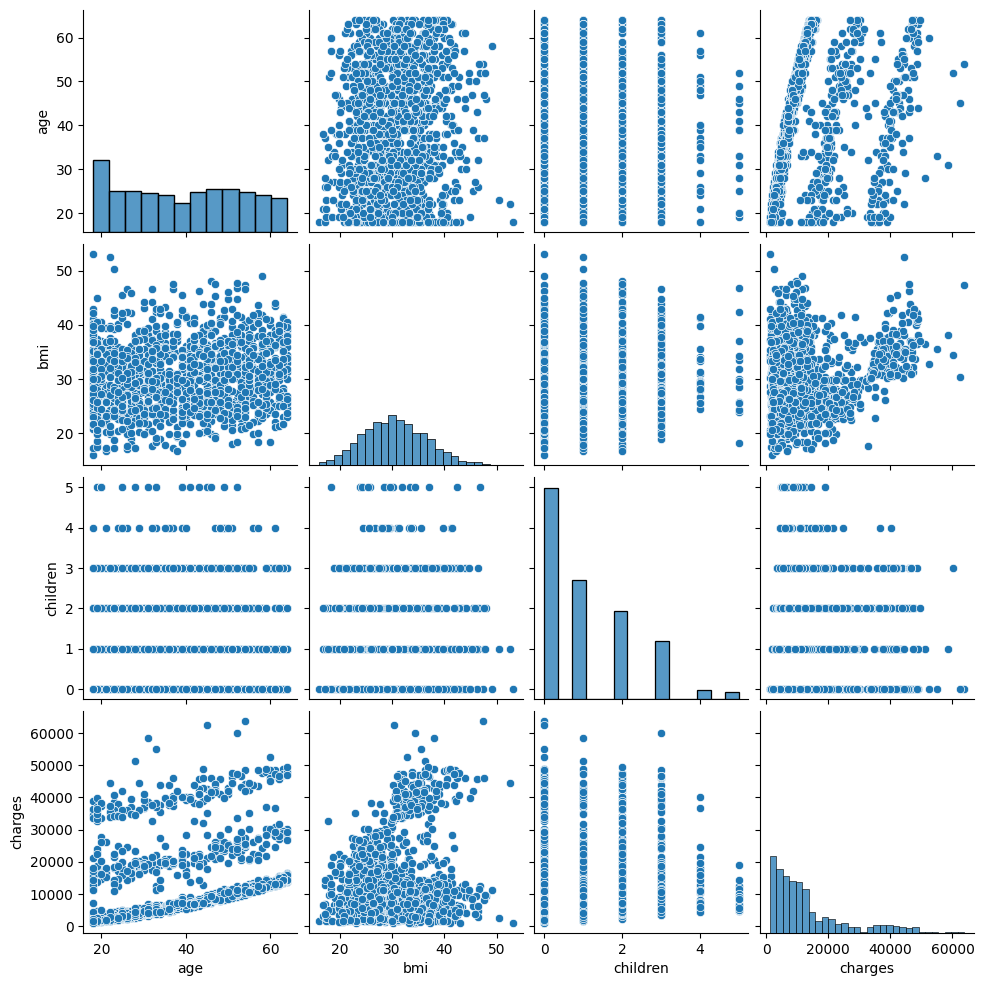

In [14]:
# Pairplot
sns.pairplot(df)
plt.show()


## Predictive Modelling

In [17]:
X = df[["age", "bmi", "children"]]
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [18]:
#linear regression 
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

lr_r2 = r2_score(y_test, lr_preds)
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

print("Linear Regression Performance:")
print("R²   :", round(lr_r2, 4))
print("MAE  :", round(lr_mae, 2))
print("RMSE :", round(lr_rmse, 2))

# Coefficients
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

print("\nLinear Regression Coefficients:")
display(coef_df)


Linear Regression Performance:
R²   : 0.1549
MAE  : 9181.31
RMSE : 11454.32

Linear Regression Coefficients:


,Feature,Coefficient
0,age,220.757765
1,bmi,332.202476
2,children,563.019432


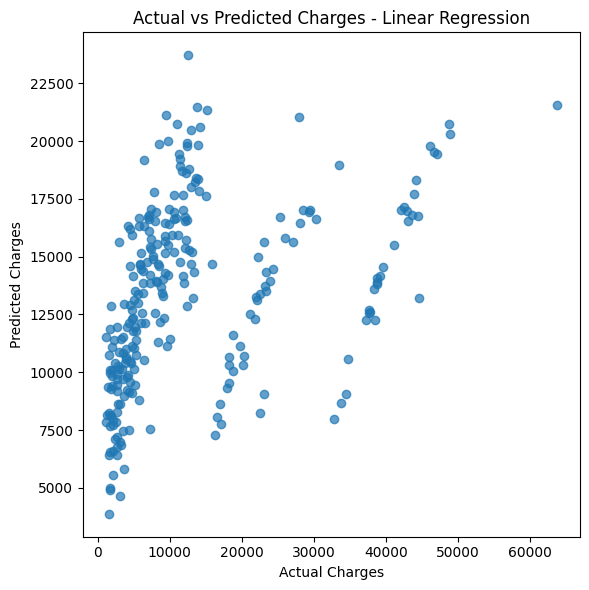

In [19]:
# Actual vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test, lr_preds, alpha=0.7)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges - Linear Regression")
plt.tight_layout()
plt.show()


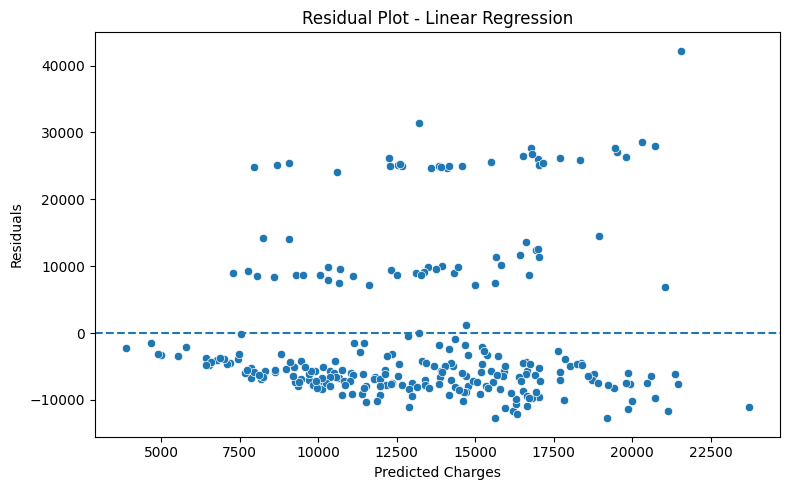

In [20]:
# Residual plot
lr_residuals = y_test - lr_preds

plt.figure(figsize=(8, 5))
sns.scatterplot(x=lr_preds, y=lr_residuals)
plt.axhline(0, linestyle="--")
plt.title("Residual Plot - Linear Regression")
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()


In [21]:
# 10. Random Forest Regressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, rf_preds)
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

print("Random Forest Performance:")
print("R²   :", round(rf_r2, 4))
print("MAE  :", round(rf_mae, 2))
print("RMSE :", round(rf_rmse, 2))


Random Forest Performance:
R²   : -0.0251
MAE  : 9309.69
RMSE : 12615.09


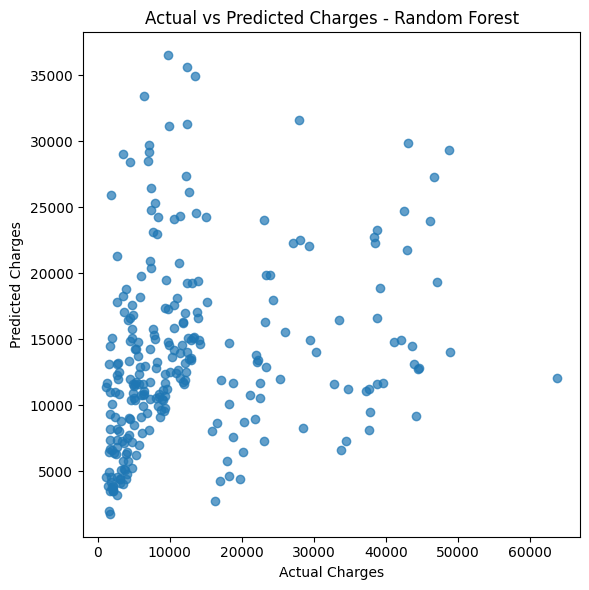

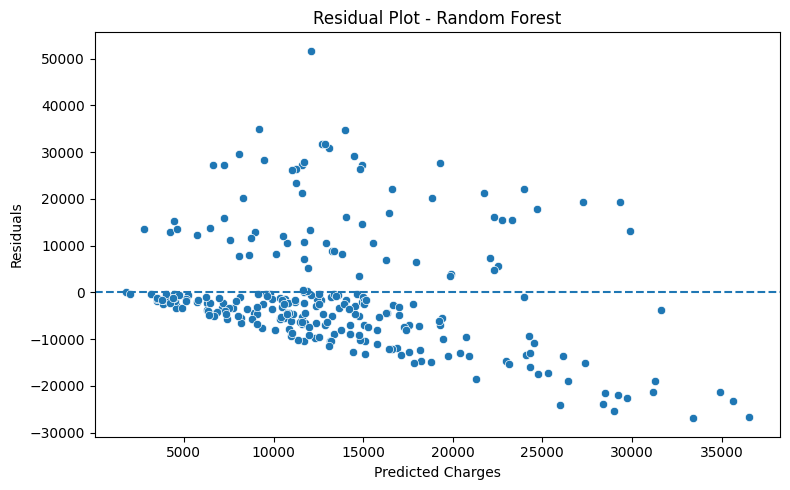

In [22]:
# Actual vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test, rf_preds, alpha=0.7)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges - Random Forest")
plt.tight_layout()
plt.show()

# Residual plot
rf_residuals = y_test - rf_preds

plt.figure(figsize=(8, 5))
sns.scatterplot(x=rf_preds, y=rf_residuals)
plt.axhline(0, linestyle="--")
plt.title("Residual Plot - Random Forest")
plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()



Random Forest Feature Importances:


,Feature,Importance
1,bmi,0.531787
0,age,0.355827
2,children,0.112386


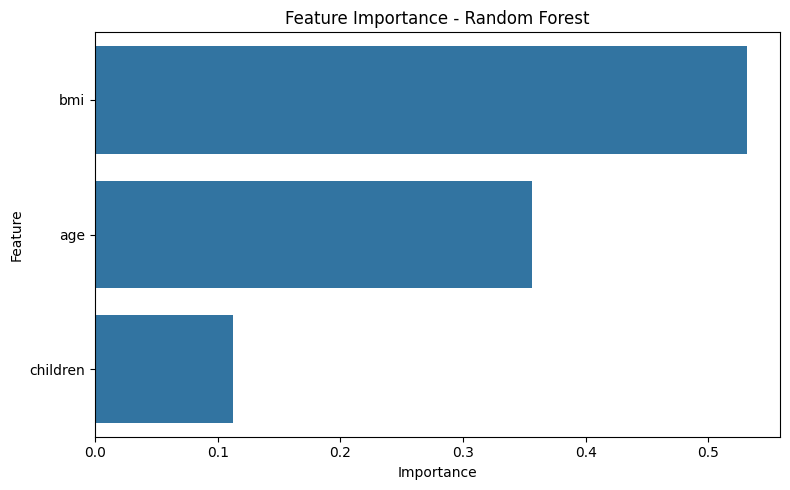

In [23]:
# Feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nRandom Forest Feature Importances:")
display(feature_importance)

plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.show()


In [24]:
# 11. Model Comparison Summary

comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2": [lr_r2, rf_r2],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse]
})

print("\nModel Comparison:")
display(comparison_df)




Model Comparison:


,Model,R2,MAE,RMSE
0,Linear Regression,0.154896,9181.311633,11454.315154
1,Random Forest,-0.025068,9309.690371,12615.089793


## Key Insights

1. Medical charges are highly right-skewed, with a small number of patients incurring very high expenses.
2. Age shows a positive relationship with healthcare costs.
3. BMI also appears positively associated with charges, especially at higher values.
4. The number of children has a weaker relationship with charges than age and BMI.
5. Linear Regression serves as a baseline model, while Random Forest helps capture more complex relationships.
6. Because the dataset contains only three predictor variables, this modeling task should be treated as a baseline cost-prediction analysis rather than a highly accurate production model.
